# Dự án Churn Prediction - Giai đoạn 1: EDA & Làm sạch dữ liệu
**Người thực hiện:** AIE Data Advisor
**Mục tiêu:** Phân tích các yếu tố dẫn đến rời bỏ dịch vụ và chuẩn bị dữ liệu sạch cho Model.

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import os

# 1. Đọc dữ liệu từ file raw
# Lưu ý: ../ nghĩa là lùi ra khỏi thư mục notebooks để vào thư mục data
raw_data_path = r"D:\AIO Tài liệu\Warm up 04\Project\Churn-Prediction\data\raw\E Commerce Dataset.xlsx"
df = pd.read_excel(raw_data_path)

# 2. Chia dữ liệu ngay lập tức (80% Train, 20% Test)
# stratify=df['Churn'] đảm bảo tỷ lệ khách rời bỏ ở 2 tập là như nhau
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Churn'])

# 3. Tạo thư mục processed nếu chưa có và lưu lại
os.makedirs('../data/processed', exist_ok=True)
train_df.to_csv('../data/processed/train.csv', index=False)
test_df.to_csv('../data/processed/test.csv', index=False)

print(f"Thành công! Tập Train có {len(train_df)} dòng, tập Test có {len(test_df)} dòng.")

KeyError: 'Churn'

In [3]:
xl = pd.ExcelFile(r"D:\AIO Tài liệu\Warm up 04\Project\Churn-Prediction\data\raw\E Commerce Dataset.xlsx")
print("Danh sách các sheet có trong file:", xl.sheet_names)

Danh sách các sheet có trong file: ['Data Dict', 'E Comm']


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
import os

# 1. Đường dẫn (Sử dụng r"" để tránh lỗi gạch chéo)
path = r"D:\AIO Tài liệu\Warm up 04\Project\Churn-Prediction\data\raw\E Commerce Dataset.xlsx"

# 2. Đọc Sheet thứ 2 (sheet_name=1)
# Nếu máy báo lỗi "ImportError: Missing optional dependency 'openpyxl'", 
# bạn hãy vào Terminal gõ: pip install openpyxl
df = pd.read_excel(path, sheet_name="E Comm")

# 3. Làm sạch tên cột (đề phòng khoảng trắng thừa)
df.columns = df.columns.str.strip()

# Kiểm tra thử xem đã thấy cột Churn chưa
print("Danh sách cột đã tìm thấy:", df.columns.tolist())
print(f"Tổng số dòng dữ liệu: {len(df)}")

# 4. Nếu đã thấy cột 'Churn', tiến hành chia dữ liệu
if 'Churn' in df.columns:
    train_df, test_df = train_test_split(
        df, 
        test_size=0.2, 
        random_state=42, 
        stratify=df['Churn']
    )
    
    # 5. Lưu vào thư mục processed
    os.makedirs('../data/processed', exist_ok=True)
    train_df.to_csv('../data/processed/train.csv', index=False)
    test_df.to_csv('../data/processed/test.csv', index=False)
    print("--- THÀNH CÔNG: Đã chia Train/Test và lưu file! ---")
else:
    print("Vẫn chưa tìm thấy cột 'Churn'. Hãy kiểm tra lại tên Sheet!")

Danh sách cột đã tìm thấy: ['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']
Tổng số dòng dữ liệu: 5630
--- THÀNH CÔNG: Đã chia Train/Test và lưu file! ---


In [5]:
df = pd.read_excel(path, sheet_name='E Comm')

In [6]:
train_df.isnull().sum()

CustomerID                       0
Churn                            0
Tenure                         213
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                206
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 197
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    208
CouponUsed                     208
OrderCount                     212
DaySinceLastOrder              247
CashbackAmount                   0
dtype: int64

In [7]:
# 1. Danh sách các cột cần vá (Numerical columns)
cols_to_fix = [
    'Tenure', 'WarehouseToHome', 'HourSpendOnApp', 
    'OrderAmountHikeFromlastYear', 'CouponUsed', 
    'OrderCount', 'DaySinceLastOrder'
]

# 2. Vá lỗi bằng Median (Trung vị)
for col in cols_to_fix:
    median_val = train_df[col].median()
    train_df[col] = train_df[col].fillna(median_val)

# 3. Kiểm tra lại xem còn lỗ hổng nào không
print("Số lượng giá trị thiếu sau khi vá:")
print(train_df.isnull().sum().sum())

Số lượng giá trị thiếu sau khi vá:
0


In [8]:
print(train_df['Churn'].value_counts(normalize=True) * 100)

Churn
0    83.170515
1    16.829485
Name: proportion, dtype: float64


In [9]:
# Tách các cột chữ ra để xử lý
cat_cols = train_df.select_dtypes(include=['object']).columns
print("Các cột cần chuyển đổi:", cat_cols.tolist())

# Sử dụng One-Hot Encoding (Tạo ra các cột 0 và 1)
train_df_encoded = pd.get_dummies(train_df, columns=cat_cols, drop_first=True)

print(f"Số lượng cột sau khi Encoding: {train_df_encoded.shape[1]}")

Các cột cần chuyển đổi: ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']
Số lượng cột sau khi Encoding: 31


C:\Users\tpbin\AppData\Local\Temp\ipykernel_8088\3227000729.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train_df.select_dtypes(include=['object']).columns


In [10]:
# Kiểm tra số lượng dòng trùng lặp
duplicate_count = train_df.duplicated().sum()
print(f"Số lượng dòng trùng lặp: {duplicate_count}")

# Nếu có, chúng ta sẽ xóa bỏ và chỉ giữ lại dòng đầu tiên
if duplicate_count > 0:
    train_df = train_df.drop_duplicates()
    print("Đã xóa các dòng trùng lặp!")

Số lượng dòng trùng lặp: 0


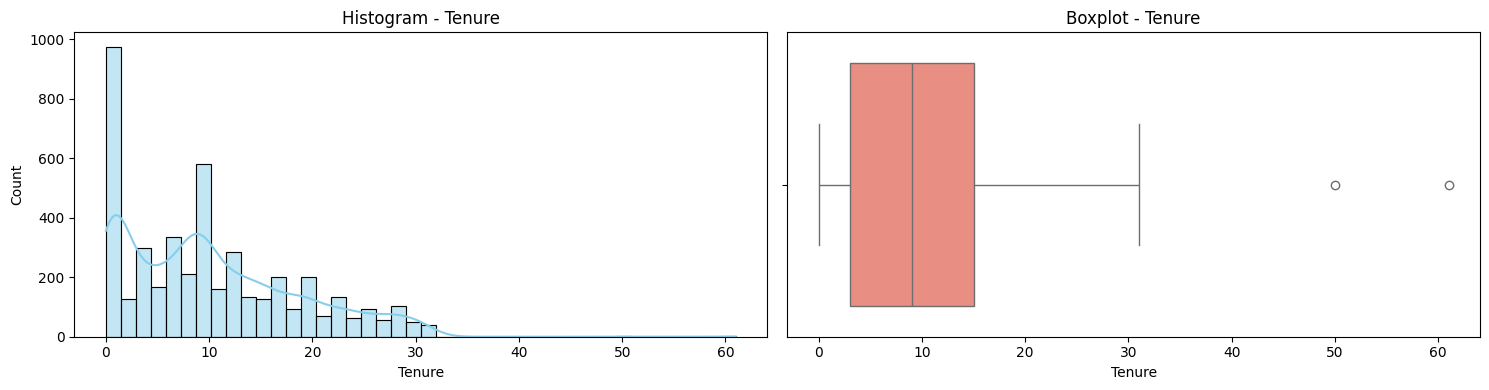

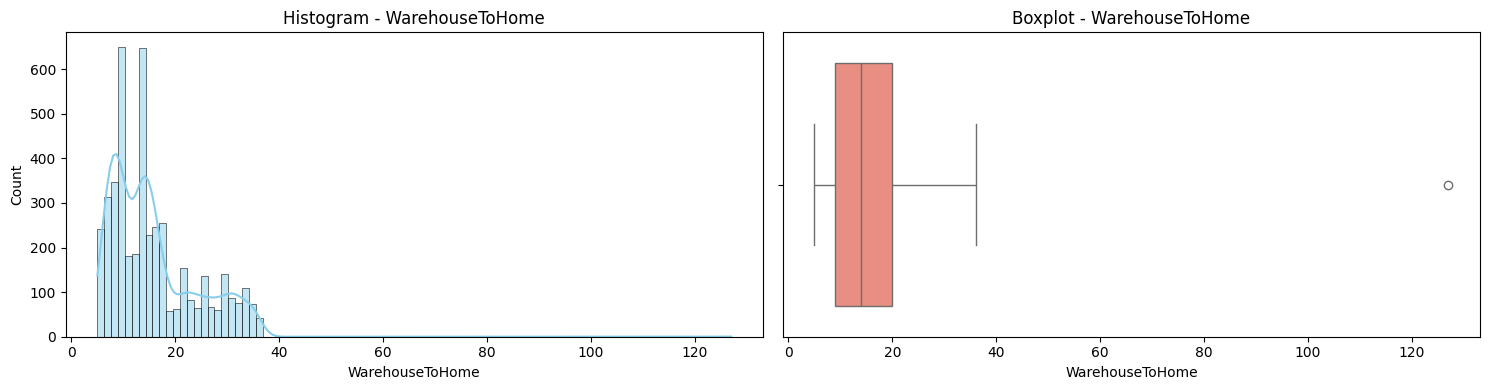

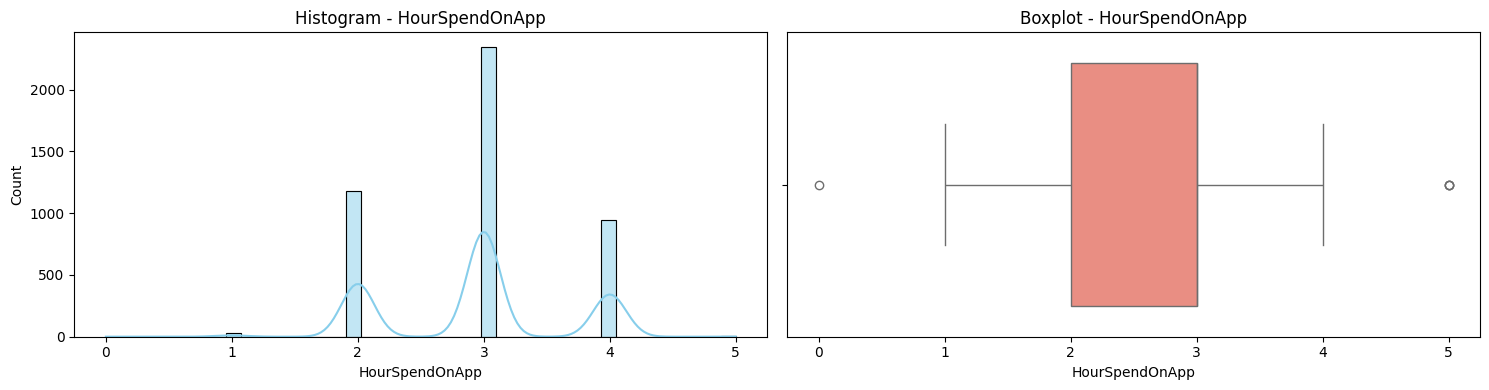

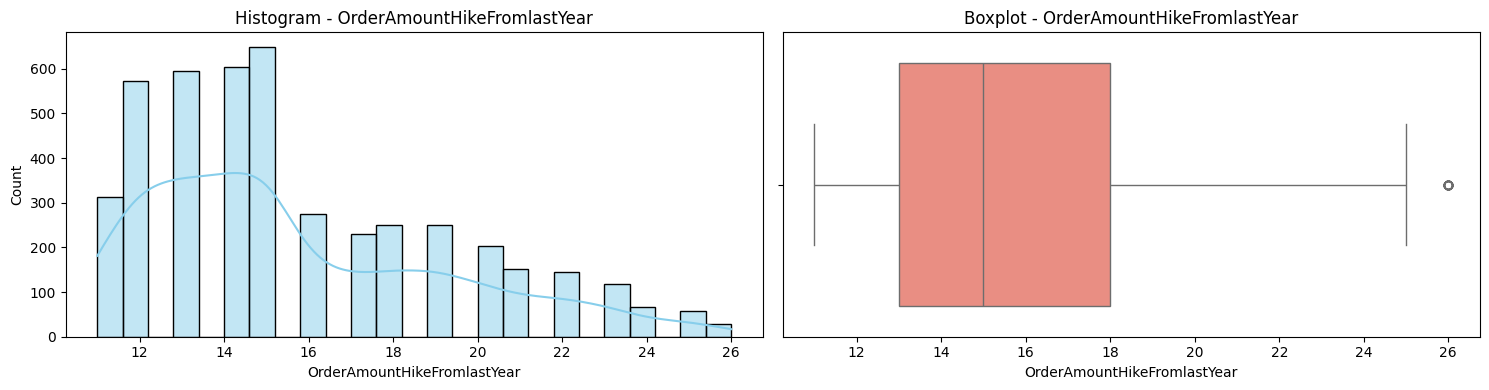

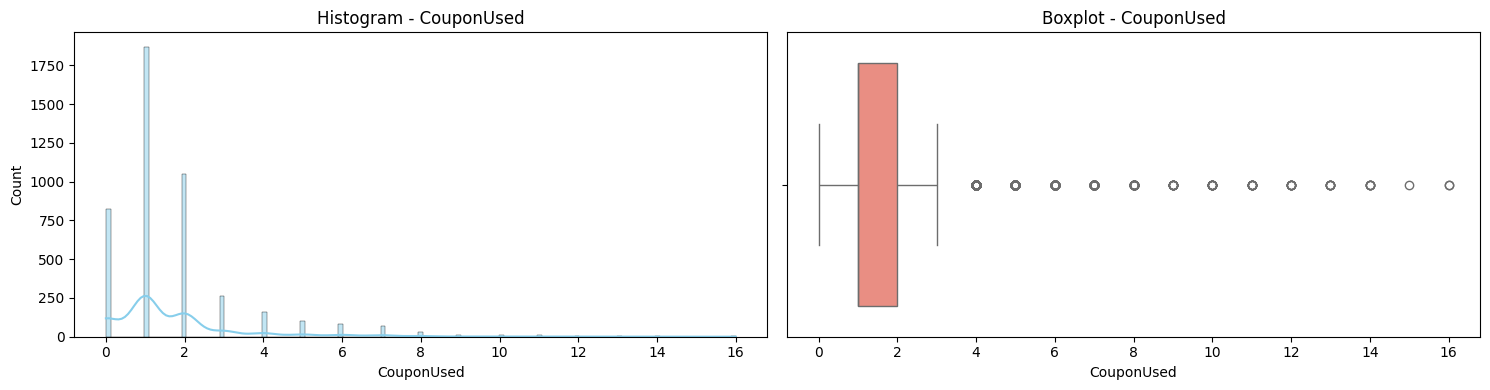

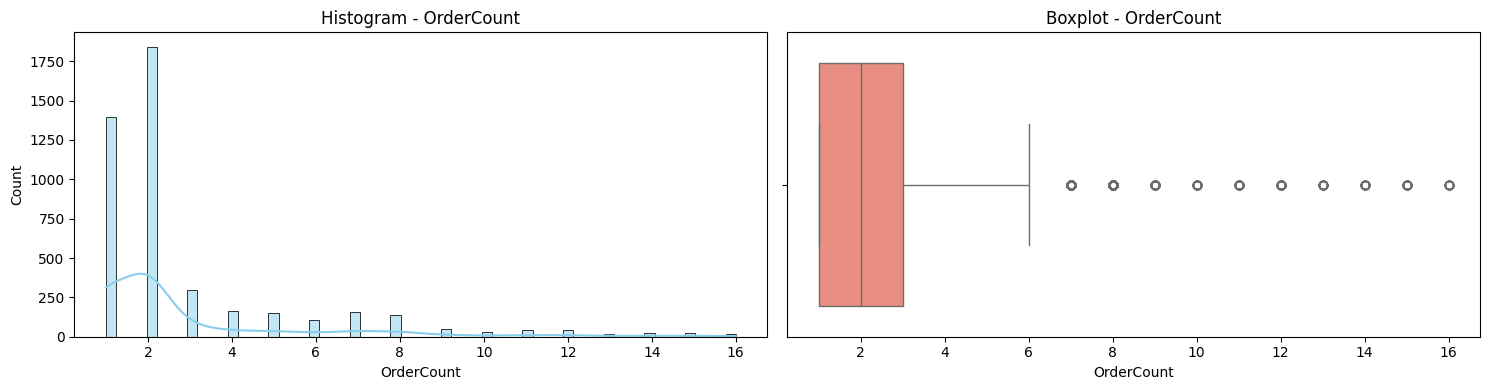

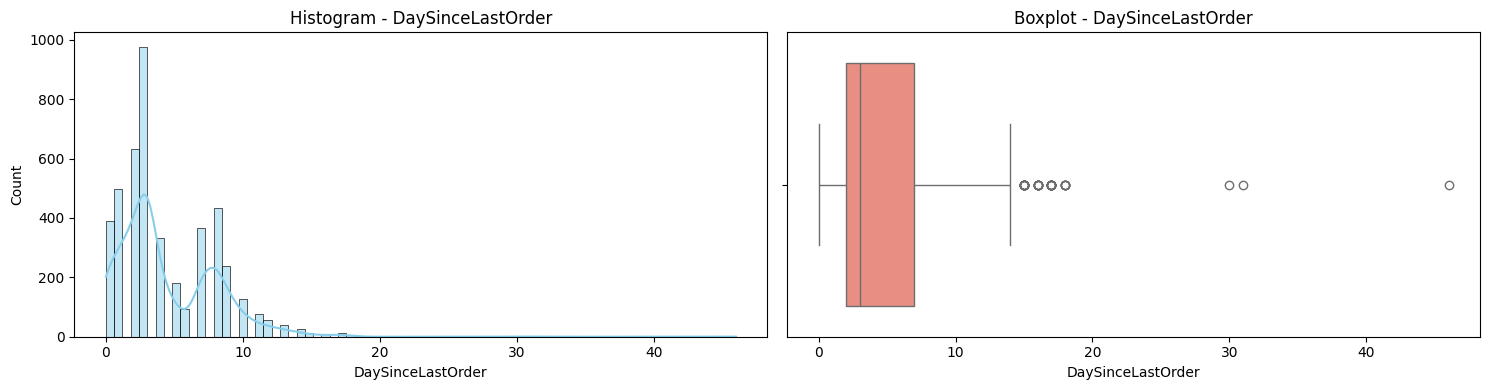

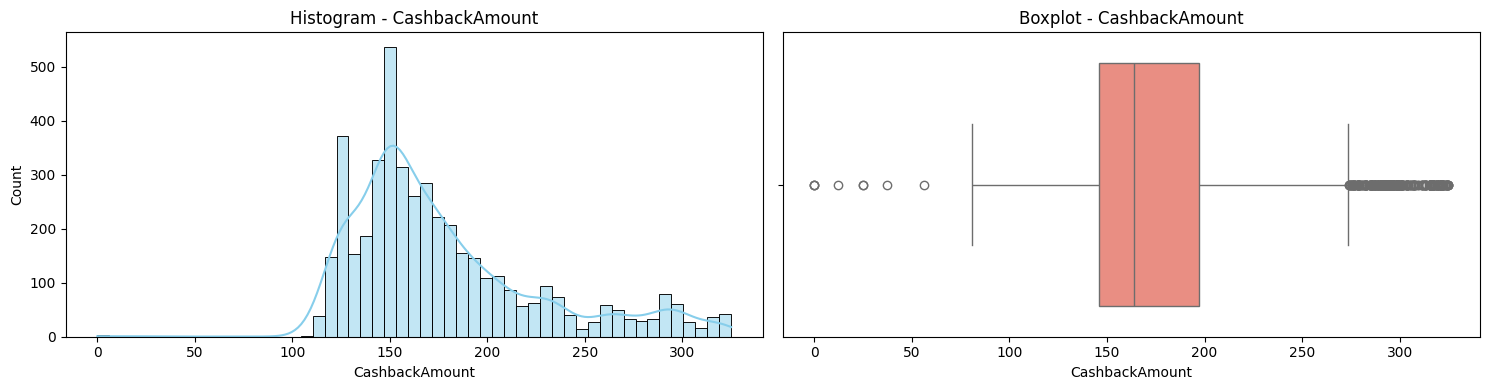

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

def survey_distributions(df, columns):
    """
    Hàm vẽ biểu đồ Histogram và Boxplot để khảo sát phân phối dữ liệu.
    """
    for col in columns:
        fig, axes = plt.subplots(1, 2, figsize=(15, 4))
        
        # 1. Biểu đồ Histogram (Mật độ)
        sns.histplot(df[col], kde=True, ax=axes[0], color='skyblue')
        axes[0].set_title(f'Histogram - {col}')
        
        # 2. Biểu đồ Boxplot (Điểm dị biệt)
        sns.boxplot(x=df[col], ax=axes[1], color='salmon')
        axes[1].set_title(f'Boxplot - {col}')
        
        plt.tight_layout()
        plt.show()

# Danh sách các cột số cần khảo sát
num_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 
            'OrderAmountHikeFromlastYear', 'CouponUsed', 
            'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

# Gọi hàm thực thi
survey_distributions(train_df, num_cols)

In [20]:
# 1. Tìm tất cả các cột số
num_features = train_df.select_dtypes(include=['int64', 'float64']).columns

# 2. Tính toán tỷ lệ Outlier ở mỗi cột
def count_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((df[col] < lower) | (df[col] > upper)).sum()

for col in num_features:
    outlier_count = count_outliers(train_df, col)
    if outlier_count > 0:
        percentage = (outlier_count / len(train_df)) * 100
        print(f"Cột {col}: có {outlier_count} outliers ({percentage:.2f}%)")

Cột Churn: có 758 outliers (16.83%)
Cột Tenure: có 2 outliers (0.04%)
Cột WarehouseToHome: có 1 outliers (0.02%)
Cột HourSpendOnApp: có 4 outliers (0.09%)
Cột NumberOfDeviceRegistered: có 327 outliers (7.26%)
Cột NumberOfAddress: có 3 outliers (0.07%)
Cột OrderAmountHikeFromlastYear: có 28 outliers (0.62%)
Cột CouponUsed: có 502 outliers (11.15%)
Cột OrderCount: có 545 outliers (12.10%)
Cột DaySinceLastOrder: có 42 outliers (0.93%)
Cột CashbackAmount: có 343 outliers (7.62%)


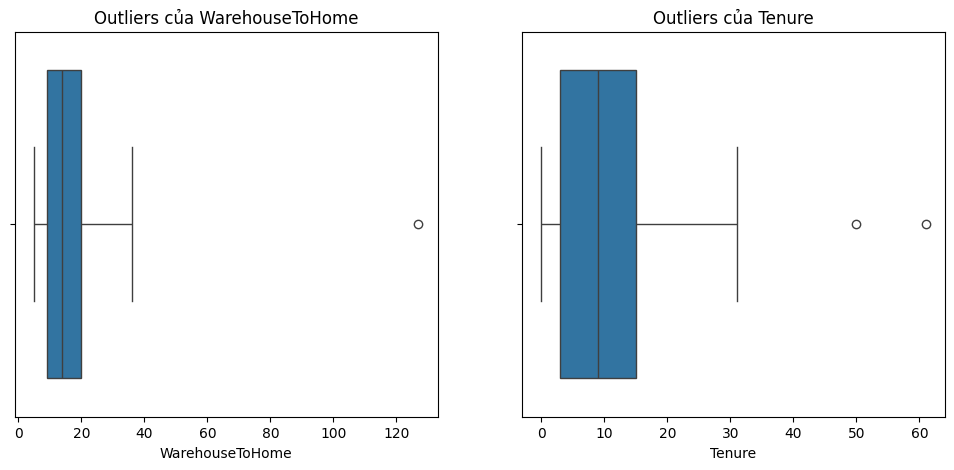

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Vẽ Boxplot cho các cột nghi vấn
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=train_df['WarehouseToHome'])
plt.title('Outliers của WarehouseToHome')

plt.subplot(1, 2, 2)
sns.boxplot(x=train_df['Tenure'])
plt.title('Outliers của Tenure')

plt.show()

In [15]:
import sys
!{sys.executable} -m pip install seaborn matplotlib pandas scikit-learn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\tpbin\AppData\Local\Temp\ipykernel_23716\3793832947.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='viridis')


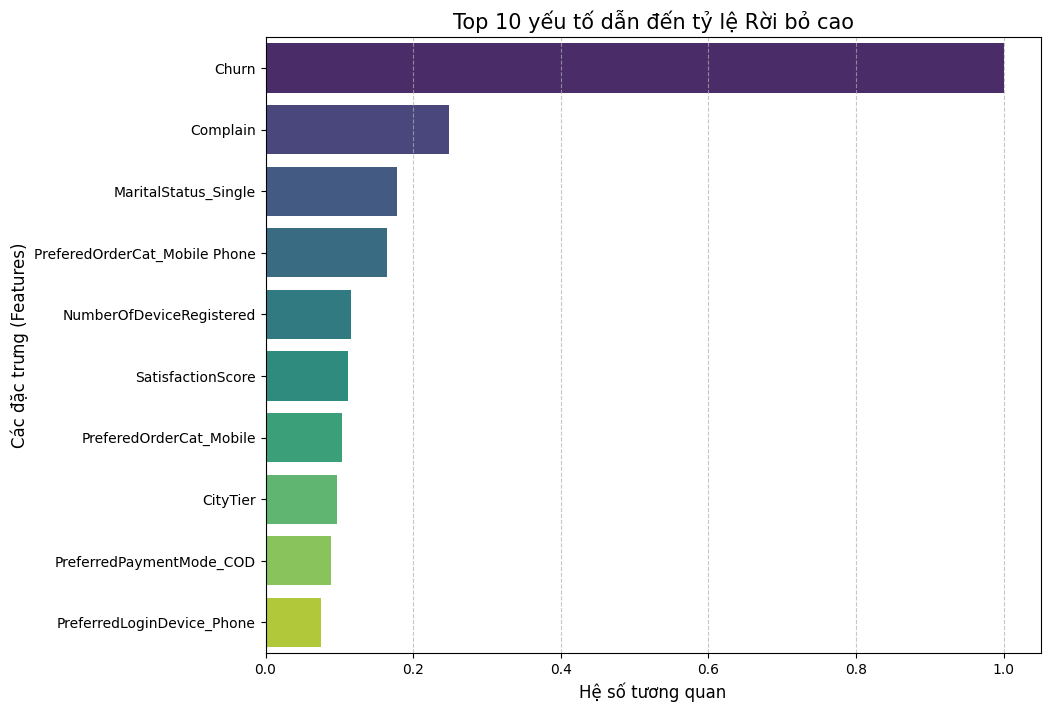

Chỉ số tương quan cụ thể:
Churn                            1.000000
Complain                         0.247916
MaritalStatus_Single             0.178380
PreferedOrderCat_Mobile Phone    0.163956
NumberOfDeviceRegistered         0.115361
SatisfactionScore                0.111479
PreferedOrderCat_Mobile          0.103470
CityTier                         0.096892
PreferredPaymentMode_COD         0.088613
PreferredLoginDevice_Phone       0.075612
Name: Churn, dtype: float64


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Tính toán độ tương quan
corr_matrix = train_df_encoded.corr()

# 2. Lấy ra top 10 biến có tương quan thuận (tích cực) nhất với Churn
# (Những yếu tố càng cao thì khách hàng càng dễ rời bỏ)
top_corr = corr_matrix['Churn'].sort_values(ascending=False).head(10)

# 3. Vẽ biểu đồ thanh
plt.figure(figsize=(10, 8))
sns.barplot(x=top_corr.values, y=top_corr.index, palette='viridis')

plt.title('Top 10 yếu tố dẫn đến tỷ lệ Rời bỏ cao', fontsize=15)
plt.xlabel('Hệ số tương quan', fontsize=12)
plt.ylabel('Các đặc trưng (Features)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 4. In ra các con số cụ thể để Advisor soi kỹ hơn
print("Chỉ số tương quan cụ thể:")
print(top_corr)

In [17]:
# Lưu tập dữ liệu đã sạch hoàn toàn vào thư mục processed
train_df_encoded.to_csv('../data/processed/train_final_v1.csv', index=False)
print("--- DỮ LIỆU ĐÃ SẴN SÀNG CHO MODELING ---")

--- DỮ LIỆU ĐÃ SẴN SÀNG CHO MODELING ---


In [ ]:
import pandas as pd

# A. ĐỊNH NGHĨA LẠI HÀM 
def handle_outliers(df, column):
    # Sử dụng phương pháp IQR (Interquartile Range) [cite: 576]
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Capping: Thay thế giá trị ngoài biên bằng giá trị biên [cite: 576]
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

# B. THỰC HIỆN XỬ LÝ CHIẾN THUẬT [cite: 642]
# Chỉ cắt những cột có Outlier cực thấp (<1%) để tránh mất tín hiệu quan trọng 
cols_to_cap = ['WarehouseToHome', 'Tenure', 'DaySinceLastOrder']

for col in cols_to_cap:
    train_df = handle_outliers(train_df, col)

# C. CHUẨN HÓA LẦN CUỐI (Encoding) [cite: 114, 503, 642]
cat_cols = train_df.select_dtypes(include=['object']).columns
train_final = pd.get_dummies(train_df, columns=cat_cols, drop_first=True)

# D. LƯU FILE "VÀNG" [cite: 595, 642]
import os
os.makedirs('../data/processed', exist_ok=True)
train_final.to_csv('../data/processed/train_final.csv', index=False)

print("--- CHÚC MỪNG: DỮ LIỆU ĐÃ SẠCH VÀ CHUẨN CHIẾN THUẬT! ---")
print(f"Số lượng cột cuối cùng: {train_final.shape[1]}")

--- CHÚC MỪNG: DỮ LIỆU ĐÃ SẠCH VÀ CHUẨN CHIẾN THUẬT! ---
Số lượng cột cuối cùng: 31


C:\Users\tpbin\AppData\Local\Temp\ipykernel_23716\3332662795.py:24: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train_df.select_dtypes(include=['object']).columns
